# Wakefield: varying a parameter

The wake depends on the shape, so a natural study is to **sweep a geometry parameter** and watch the impedance and loss factor respond. Here we vary the iris radius `Ri` of a single-cell elliptical cavity and compare.

> Needs the bundled `ABCI.exe` (Windows) / `abci` on PATH; ABCI needs a beam pipe at **both** ends.

In [1]:
import os, tempfile
import numpy as np
import matplotlib.pyplot as plt
from cavsim2d import Study, EllipticalCavity
from cavsim2d.utils.style import apply_style, WARM
apply_style()

WF = {'MROT': 0, 'wakelength': 20, 'bunch_length': 25}   # longitudinal is enough here

## A study of three iris radii

The mid-cell template is the TESLA cell; only the iris `Ri` (index 4 of `[A, B, a, b, Ri, L, Req]`) changes. A wider iris couples the beam to the pipe more, lowering the impedance.

In [2]:
base = [42, 42, 12, 19, 35, 57.7, 103.353]
radii = [30, 35, 40]
study = Study(os.path.join(tempfile.mkdtemp(), 'sweep'))
cavs, names = [], []
for Ri in radii:
    cell = base.copy(); cell[4] = Ri
    cavs.append(EllipticalCavity(1, cell, cell, cell, beampipe='both', name=f'Ri{Ri}'))
    names.append(f'Ri = {Ri} mm')
study.add_cavity(cavs, names)
study.run_wakefield(WF)

## Impedance vs iris radius

Overlay each cavity's longitudinal impedance on one axis.

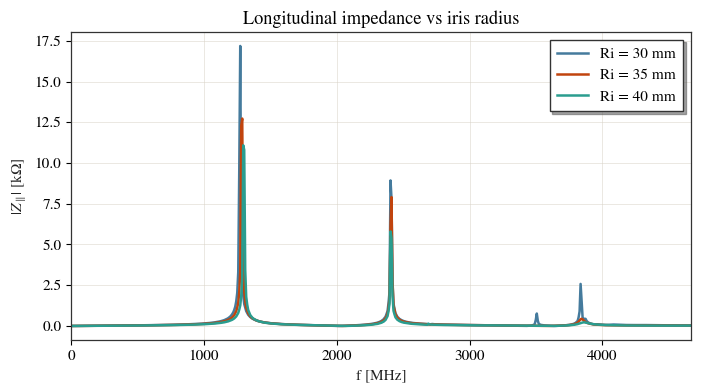

In [3]:
ax = None
for cav, name in zip(cavs, names):
    ax = cav.wakefield.plot_impedance('longitudinal', ax=ax, show=False, label=name)
ax.legend(); ax.set_title('Longitudinal impedance vs iris radius'); plt.show()

## Loss factor vs iris radius

The single-number loss factor $|k_\mathrm{loss}|$ falls as the iris opens.

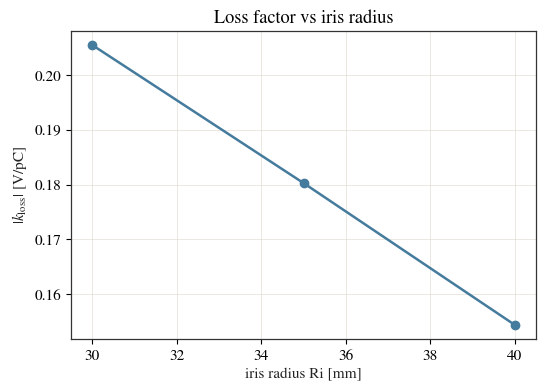

In [4]:
kloss = [cav.wakefield.qois['|k_loss| [V/pC]'] for cav in cavs]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(radii, kloss, 'o-', color=WARM[0])
ax.set_xlabel('iris radius Ri [mm]'); ax.set_ylabel(r'$|k_\mathrm{loss}|$ [V/pC]')
ax.set_title('Loss factor vs iris radius'); plt.show()

## Where to go next

- The per-geometry examples: [spline](spline.ipynb) · [RF gun](rfgun.ipynb) · [reentrant](reentrant.ipynb).
- [Comparing several cavities](../eigenmode/compare_cavities.ipynb) does the same for eigenmode QOIs.
- [Wakefield under uncertainty](../advanced/wakefield_uq.ipynb) sweeps a parameter *randomly*.